# Regresores logísticos - Modelos lineales de clasificación

Vamos a trabajar con el dataset conocido como *Wisconsin Diagnostic Breast Cancer Database* (WDBC), que es un conjunto de datos muy utilizado en el aprendizaje automático y la bioinformática para el diagnóstico de cáncer de mama.  Contiene información sobre biopsias de mama y se usa comúnmente para entrenar modelos de clasificación que puedan distinguir entre tumores benignos y malignos.

Este dataset fue creado por el Dr. William H. Wolberg, el Dr. W. Nick Street y colaboradores, y está disponible públicamente en el repositorio de *Machine Learning* de la Universidad de California en Irvine (UCI).

**Contenido del Dataset:**

El WDBC contiene 569 instancias (observaciones) de biopsias de mama.  Cada instancia está descrita por 32 atributos:

* **ID number:** Identificador único de la muestra (no relevante para el análisis).
* **Diagnosis:**  La variable objetivo o clase. Indica si el tumor es maligno (M) o benigno (B).  Este es el valor que queremos predecir.
* **30 características numéricas reales:**  Estas son las medidas obtenidas a partir de las imágenes digitalizadas de las biopsias.  Se calculan 10 características para cada una de las tres dimensiones (radio, textura y perímetro) de la imagen de la masa celular:
    * **Radio:**  Promedio del radio de la masa.
    * **Textura:**  Desviación estándar de la escala de grises.
    * **Perímetro:**  Tamaño del contorno de la masa.
    * **Área:**  Área de la masa.
    * **Suavidad:**  Medida de la suavidad de la masa.
    * **Compacidad:**  Compacidad de la masa (derivada del perímetro y el área).
    * **Concavidad:**  Número de porciones cóncavas del contorno.
    * **Puntos cóncavos:**  Número de puntos extremos cóncavos del contorno.
    * **Simetría:**  Medida de la simetría de la masa.
    * **Dimensión fractal:**  "Costa" aproximada.

    Para cada una de estas 10 características, se proporcionan tres valores:
        * **Media:**  El valor promedio de la característica.
        * **Desviación Estándar:**  La variabilidad de la característica.
        * **Peor (o Máximo):**  El valor máximo de la característica.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data', header=None)
cols = ['ID', 'Diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean',
        'concavity_mean', 'concave_points_mean', 'simmetry_mean', 'fractal_dim_mean', 'radius_sd', 'texture_sd', 'perimeter_sd',
        'area_sd', 'smoothness_sd', 'compactness_sd', 'concavity_sd', 'concave_points_sd', 'simmetry_sd', 'fractal_dim_sd',
        'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst',
        'concavity_worst', 'concave_points_worst', 'simmetry_worst', 'fractal_dim_worst']
df.columns = cols
df.set_index('ID', inplace=True)
df.head()

,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,simmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,simmetry_worst,fractal_dim_worst
ID,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Vamos a crear un modelo de regresión logística para predecir la variable **Diagnosis**, que es una variable binaria.

In [ ]:
df.Diagnosis.value_counts()

,count
Diagnosis,
B,357
M,212


In [ ]:
# Extraccion de matrices de caracteristicas y objetivo, y division de los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=72, train_size=0.8)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (455, 30)
Tamaño del conjunto de prueba es: (114, 30)


Vamos a empezar con un modelo de regresión logística sin regularizar.

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty=None, solver='saga', max_iter=10000)
model.fit(X_train, y_train)
print(f'La exactitud de este modelo con los datos de entrenamiento es: {model.score(X_train, y_train):.3f}')
print(f'La exactitud de este modelo con los datos de prueba es: {model.score(X_test, y_test):.3f}')

La exactitud de este modelo con los datos de entrenamiento es: 0.923
La exactitud de este modelo con los datos de prueba es: 0.904


¿Qué significa este resultado?

# Métricas de evaluación

Para entender este resultado, veamos la matriz de confusión.

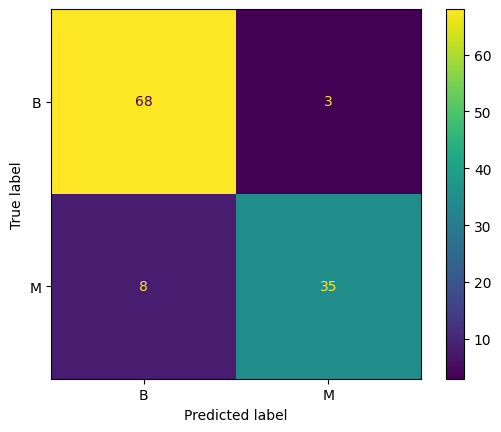

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test);

El método score está entregando la exactitud (*accuracy*) del modelo, que es el porcentaje de aciertos del modelo, bien sea positivos o negativos.

La clase **classification report** nos entrega lel resumen de todas las métricas.

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, model.predict(X_test)));

              precision    recall  f1-score   support

           B       0.89      0.96      0.93        71
           M       0.92      0.81      0.86        43

    accuracy                           0.90       114
   macro avg       0.91      0.89      0.89       114
weighted avg       0.90      0.90      0.90       114



Como este es un modelo lineal, podemos obtener los coeficientes asociados a cada característica:

In [ ]:
coeficientes = pd.DataFrame(model.coef_.reshape(-1,1), index=X_train.columns, columns=['Coeficiente'])
coeficientes.loc['Intercepto'] = model.intercept_
coeficientes

,Coeficiente
radius_mean,-0.018664
texture_mean,-0.000011
perimeter_mean,-0.088131
area_mean,-0.018930
smoothness_mean,-0.000064
compactness_mean,0.000688
concavity_mean,0.001197
concave_points_mean,0.000464
simmetry_mean,-0.000092
fractal_dim_mean,-0.000089


# Ejercicio

Haga un modelo de regresión logística para predecir el nivel de ingreso usando el dataset disponible en http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data.

Elimine las variables **native-country** y **education**.

Elimine los datos nulos.

Codifique las variables categóricas one-hot y estandarice las numéricas con StandardScaler.

Reporte el *accuracy* de entrenamiento y el de prueba.

Presente la matriz de confusión, el reporte de clasificación, y analice los resultados obtenidos. ¿El modelo está balanceado? ¿Con qué clase tiene mejor desempeño?

Reporte los coeficientes del modelo entrenado.